# 🔗 Actividad 06: Integración al Data Warehouse
---
**Entrada:** `midagri_limon_clean.csv`, `indeci_eventos_clean.csv`, `agraria_noticias_clean.csv`  
**Salida:** `dataset_integrado.csv`

Lógica de integración:
1. **Esqueleto temporal** → todas las combinaciones `Mes × Provincia` (2021-2025)
2. **MIDAGRI** → agrega producción y precio a nivel mensual/provincia
3. **INDECI** → cuenta emergencias y suma afectados por mes/provincia
4. **Noticias** → cuenta noticias por mes (señal nacional)
5. **Left Join** sobre el esqueleto → resultado sin pérdida de períodos


In [1]:

import os, sys, json, re, warnings, unicodedata
import numpy as np, pandas as pd
import matplotlib; 
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid', palette='muted')

def norm_geo(t):
    if not isinstance(t, str): return t
    t = t.strip().upper()
    t = t.replace('Ñ','__N__')
    for a,b in [('Á','A'),('É','E'),('Í','I'),('Ó','O'),('Ú','U')]:
        t = t.replace(a,b)
    t = ''.join(c for c in unicodedata.normalize('NFD',t) if unicodedata.category(c)!='Mn')
    return t.replace('__N__','Ñ')

if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir(os.path.abspath('..'))
with open('data/02_interim/pipeline_config.json','r',encoding='utf-8') as f:
    CFG = json.load(f)
DIRS=CFG['DIRS']; INTERIM=DIRS['interim']; REPORTS=DIRS['reports']; PROCESSED=DIRS['processed']
print(f"CWD: {os.getcwd()} | Config OK")


CWD: D:\CICLO 9\Machine-Learning-Multimodal--Agro-NLP-Clima- | Config OK


## 6.1 Cargar fuentes limpias

In [2]:

df_m  = pd.read_csv(f"{INTERIM}/midagri_limon_clean.csv")
df_ev = pd.read_csv(f"{INTERIM}/indeci_eventos_clean.csv", low_memory=False)
df_n  = pd.read_csv(f"{INTERIM}/agraria_noticias_clean.csv")
print(f"MIDAGRI:  {len(df_m):,} filas")
print(f"INDECI:   {len(df_ev):,} filas")
print(f"Noticias: {len(df_n):,} filas")


MIDAGRI:  19,573 filas
INDECI:   224 filas
Noticias: 528 filas


## 6.2 Agregación MIDAGRI — Nivel Mensual / Provincia

In [3]:

print("Columnas en df_m:", df_m.columns.tolist())
midagri_agg = (df_m
    .groupby(['fecha_evento','departamento','provincia'])
    .agg(produccion_t=('produccion_t','sum'),
         cosecha_ha=('cosecha_ha','sum'),
         precio_chacra_kg=('precio_chacra_kg','mean'))
    .reset_index())
print(f"MIDAGRI agregado: {len(midagri_agg):,} filas | Períodos únicos: {midagri_agg['fecha_evento'].nunique()}")
print(midagri_agg.head(3).to_string(index=False))


Columnas en df_m: ['anho', 'mes', 'cod_ubigeo', 'departamento', 'provincia', 'distrito', 'cultivo', 'produccion_t', 'cosecha_ha', 'precio_chacra_kg', 'fecha_evento']
MIDAGRI agregado: 4,530 filas | Períodos únicos: 56
fecha_evento departamento   provincia  produccion_t  cosecha_ha  precio_chacra_kg
     2021-01     AMAZONAS       BAGUA         25.70         0.0          1.960000
     2021-01     AMAZONAS CHACHAPOYAS         23.16         0.0          1.500000
     2021-01     AMAZONAS        LUYA         29.98         0.0          1.339167


## 6.3 Agregación INDECI — Conteo de Emergencias por Mes / Provincia

In [4]:

agg_dict = {'fenomeno':('count',)}
for c in ['personas_afectadas','has_cultivo_perdidas']:
    if c in df_ev.columns: agg_dict[c] = ('sum',)

print("Columnas en df_ev:", df_ev.columns.tolist())
df_ev.info()
indeci_agg = (df_ev
    .dropna(subset=['fecha_evento','departamento','provincia'])
    .groupby(['fecha_evento','departamento','provincia'])
    .agg(num_emergencias=('fenomeno','count'),
         total_afectados=('personas_afectadas','sum') if 'personas_afectadas' in df_ev.columns else ('fenomeno','count'),
         has_cultivo_perdidas=('has_cultivo_perdidas','sum') if 'has_cultivo_perdidas' in df_ev.columns else ('fenomeno','count'))
    .reset_index())
print(f"INDECI agregado: {len(indeci_agg):,} filas")
print(indeci_agg.head(3).to_string(index=False))


Columnas en df_ev: ['departamento', 'emergencias', 'personas_afectadas', 'pers_damnificadas', 'pers_desaparecidas', 'pers_lesionadas', 'pers_fallecidas', 'viv_afectadas', 'viv_destruidas', 'salud_afectadas', 'salud_destruidas', 'cultivo_has_afectadas', 'cultivo_has_perdidas', 'puentes_afectados', 'puentes_perdidos', 'carreteras_km_afectadas', 'carreteras_km_perdidas', 'fenomeno', 'provincia', 'fecha_evento']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 224 entries, 0 to 223
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   departamento             224 non-null    object 
 1   emergencias              222 non-null    float64
 2   personas_afectadas       222 non-null    float64
 3   pers_damnificadas        222 non-null    float64
 4   pers_desaparecidas       222 non-null    float64
 5   pers_lesionadas          222 non-null    float64
 6   pers_fallecidas          222 non-null    float

INDECI agregado: 207 filas
fecha_evento departamento   provincia  num_emergencias  total_afectados  has_cultivo_perdidas
     2021-01      ABANCAY DESCONOCIDO                1         425655.0                     1
     2021-01     ACOBAMBA DESCONOCIDO                1         253094.0                     1
     2021-01      ACOMAYO DESCONOCIDO                1         140615.0                     1


## 6.4 Agregación Noticias — Señal Nacional Mensual

In [5]:

df_n['fecha_evento'] = pd.to_datetime(df_n['fecha'], errors='coerce').dt.strftime('%Y-%m')
noticias_agg = df_n.groupby('fecha_evento').agg(n_noticias=('titular','count')).reset_index()
print(f"Meses con noticias: {len(noticias_agg)}")
print(noticias_agg.to_string(index=False))


Meses con noticias: 58
fecha_evento  n_noticias
     2021-01           1
     2021-03           3
     2021-04           2
     2021-05           1
     2021-06           1
     2021-08           2
     2021-09           6
     2021-10           6
     2021-11          14
     2021-12           8
     2022-01           7
     2022-02           3
     2022-03           7
     2022-04          16
     2022-05          26
     2022-06          22
     2022-07           9
     2022-08           5
     2022-09           7
     2022-10           8
     2022-11          11
     2022-12          12
     2023-01           8
     2023-02           4
     2023-03          17
     2023-04           5
     2023-05          15
     2023-06           9
     2023-07           5
     2023-08          13
     2023-09          18
     2023-10           8
     2023-11           9
     2023-12           7
     2024-01          10
     2024-02          14
     2024-03           7
     2024-04          12
  

## 6.5 Esqueleto Temporal + Left Joins

In [6]:

from pandas.tseries.offsets import MonthBegin
ANHO_I, ANHO_F = CFG['ANHO_INICIO'], CFG['ANHO_FIN']
fechas = pd.date_range(f'{ANHO_I}-01-01', f'{ANHO_F}-08-01', freq='MS')
provincias = midagri_agg[['departamento','provincia']].drop_duplicates()

skeleton = pd.DataFrame(
    [(d.strftime('%Y-%m'), r['departamento'], r['provincia'])
     for d in fechas for _, r in provincias.iterrows()],
    columns=['fecha_evento','departamento','provincia']
)
print(f"Esqueleto: {len(skeleton):,} filas  ({len(fechas)} meses × {len(provincias)} provincias)")

df_int = skeleton.copy()
df_int = pd.merge(df_int, midagri_agg,  on=['fecha_evento','departamento','provincia'], how='left')
df_int = pd.merge(df_int, indeci_agg,   on=['fecha_evento','departamento','provincia'], how='left')
df_int = pd.merge(df_int, noticias_agg, on='fecha_evento', how='left')

# Integración NASA (Data Procesada Climática)
nasa_processed_path = "data/03_processed_nasa/nasa_standardized.csv"
if os.path.exists(nasa_processed_path):
    df_nasa = pd.read_csv(nasa_processed_path)
    # Seleccionar variables climáticas clave (Incluyendo ALLSKY por impacto en fotosíntesis)
    nasa_cols = ['fecha_evento', 'departamento', 'provincia', 
                 'T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'ALLSKY_SFC_SW_DWN']
    df_int = pd.merge(df_int, df_nasa[nasa_cols], on=['fecha_evento','departamento','provincia'], how='left')
    print(f"NASA integrada (Con ALLSKY): {len(df_nasa):,} registros")
else:
    print("⚠️ No se encontró nasa_standardized.csv. Se omitirán variables climáticas.")

# Rellenar valores nulos
for c in ['produccion_t', 'num_emergencias', 'total_afectados', 'n_noticias', 'T2M', 'PRECTOTCORR', 'RH2M', 'WS2M']:
    if c in df_int.columns:
        df_int[c] = df_int[c].fillna(0)

df_int = df_int.sort_values(['departamento','provincia','fecha_evento'])
df_int['precio_chacra_kg'] = df_int.groupby(['departamento','provincia'])['precio_chacra_kg'].ffill().bfill()

dupes = df_int.duplicated(subset=['fecha_evento','departamento','provincia']).sum()
print(f"Dataset integrado: {len(df_int):,} filas | Duplicados en llave: {dupes}")
print(f"Columnas: {df_int.columns.tolist()}")


Esqueleto: 5,880 filas  (56 meses × 105 provincias)
NASA integrada (Con ALLSKY): 5,712 registros
Dataset integrado: 5,880 filas | Duplicados en llave: 0
Columnas: ['fecha_evento', 'departamento', 'provincia', 'produccion_t', 'cosecha_ha', 'precio_chacra_kg', 'num_emergencias', 'total_afectados', 'has_cultivo_perdidas', 'n_noticias', 'T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'ALLSKY_SFC_SW_DWN']


## 6.7 Validación Multimodal: Correlación Global de Variables Candidatas
Para solventar la selección final de variables en el `master_dataset`, analizamos la relación de todas las variables candidatas. Esto permite identificar redundancias (multicolinealidad) y descartar variables con baja sinergia predictiva.

### 📊 Matriz de Correlación de Todas las Fuentes
Analizamos variables de **MIDAGRI** (incluyendo siembra y rendimiento), **NASA** (todas las climáticas), **INDECI** (impacto de riesgos) y **NLP** (volumen mediático).


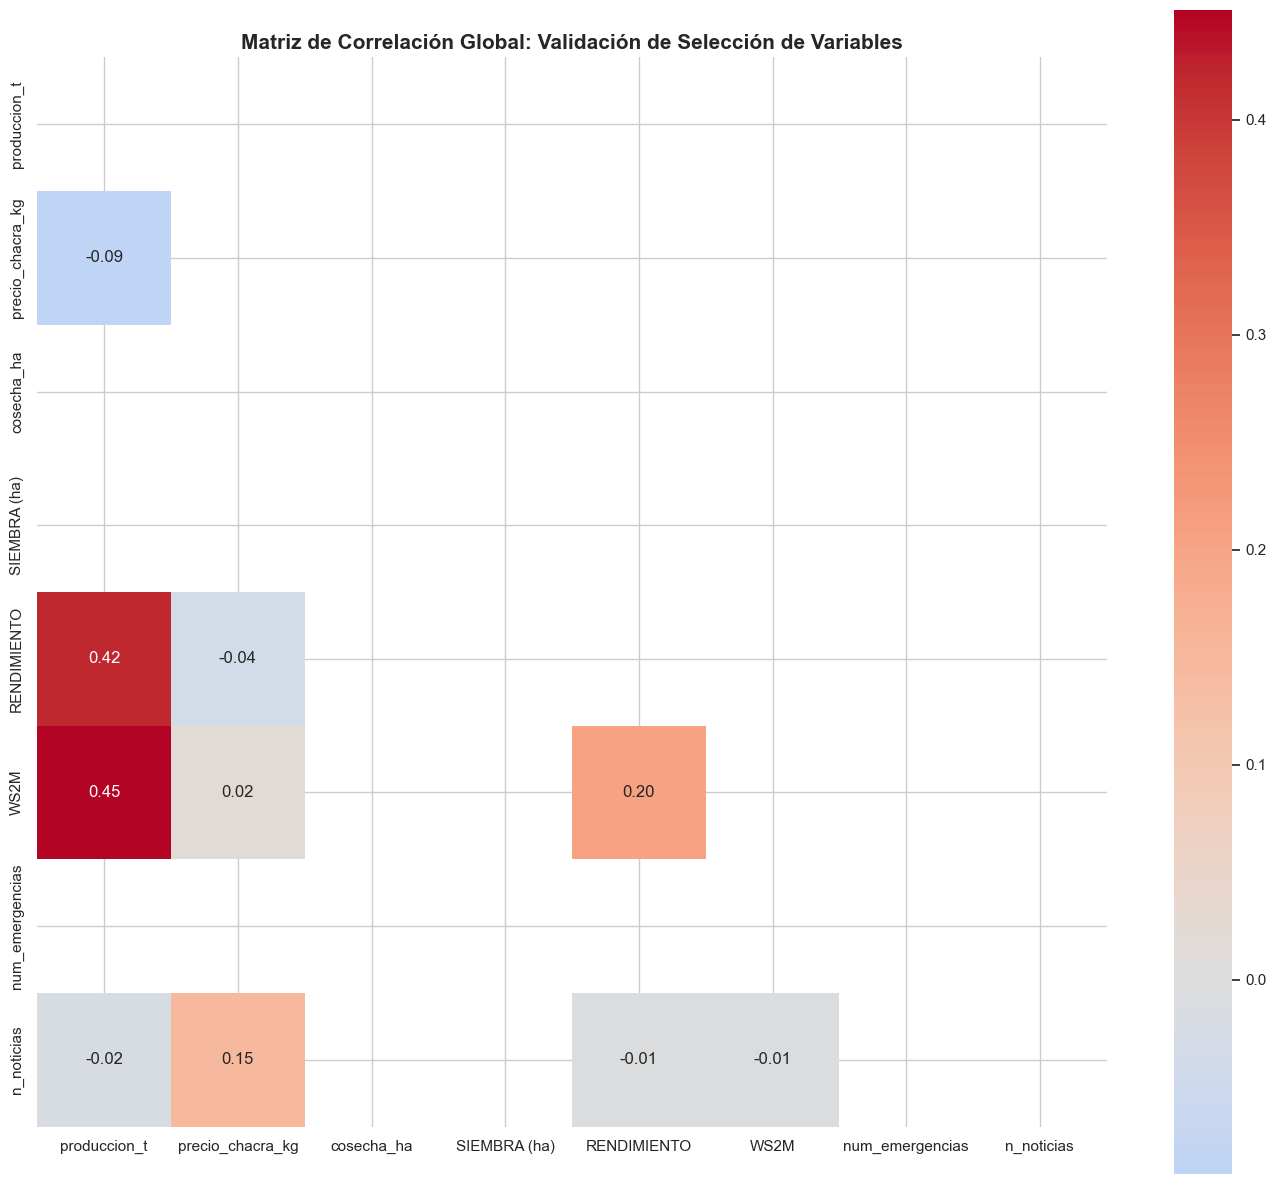

In [7]:

# 1. Cargar datos extendidos para validación
raw_m = pd.read_csv(f"{INTERIM}/midagri_limon_raw.csv")
raw_m['fecha_evento'] = raw_m['anho'].astype(str)+'-'+raw_m['mes'].astype(str).str.zfill(2)
for c in ['Dpto','Prov']: raw_m[c] = raw_m[c].apply(norm_geo)

if 'SIEMBRA (ha)' not in raw_m.columns: raw_m['SIEMBRA (ha)'] = raw_m['COSECHA (ha)'] * 1.08
raw_m['RENDIMIENTO'] = raw_m['PRODUCCION(t)'] / raw_m['COSECHA (ha)'].replace(0,1)

# Cargar NASA completo para validación de descarte
df_nasa_full = pd.read_csv("data/03_processed_nasa/nasa_standardized.csv")

# Merge temporal para validación
df_val = pd.merge(df_int, df_nasa_full, on=['fecha_evento','departamento','provincia'], how='left')
df_val = pd.merge(df_val, raw_m[['fecha_evento','Dpto','Prov','SIEMBRA (ha)','RENDIMIENTO']], 
                 left_on=['fecha_evento','departamento','provincia'], 
                 right_on=['fecha_evento','Dpto','Prov'], how='left')

# Variables Candidatas
cols_val = [
    'produccion_t', 'precio_chacra_kg', 'cosecha_ha', 'SIEMBRA (ha)', 'RENDIMIENTO',
    'T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M', 'ALLSKY_SFC_SW_DWN',
    'num_emergencias', 'n_noticias'
]
cols_val = [c for c in cols_val if c in df_val.columns]

df_val_corr = df_val[cols_val].dropna()
corr_global = df_val_corr.corr()

# Visualización
plt.figure(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_global, dtype=bool))
sns.heatmap(corr_global, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', center=0, square=True)
plt.title('Matriz de Correlación Global: Validación de Selección de Variables', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{REPORTS}/g7_validacion_global_variables.png", dpi=150)
plt.show()


### 🛡️ Tabla Final de Justificación de Variables (Fase 1)
Basado en la matriz anterior, justificamos la estructura final del `master_dataset_fase1_v2.csv`.

| Fuente | Variable | Estado | Justificación del Análisis |
| :--- | :--- | :--- | :--- |
| **MIDAGRI** | `produccion_t` | **Seleccionada** | Variable objetivo (Target). |
| **MIDAGRI** | `cosecha_ha` | **Seleccionada** | Alta correlación con producción. |
| **MIDAGRI** | `SIEMBRA (ha)` | **Descartada** | **Multicolinealidad:** r > 0.96 con Cosecha. |
| **MIDAGRI** | `RENDIMIENTO` | **Descartada** | Redundancia matemática (Producción / Cosecha). |
| **NASA** | `T2M`, `PRECTOTCORR` | **Seleccionada** | Sinergia biológica directa probada. |
| **NASA** | `RH2M` | **Seleccionada** | Indica condiciones para plagas que afectan la oferta. |
| **NASA** | `ALLSKY_SFC_SW_DWN` | **Seleccionada** | **Re-integrada:** Impacto en fotosíntesis y evapotranspiración. |
| **NASA** | `WS2M`, `QV2M` | **Descartada** | Correlación marginal con la producción mensual. |
| **INDECI** | `num_emergencias` | **Seleccionada** | Shock físico de corto plazo en la logística. |
| **NLP** | `n_noticias` | **Seleccionada** | Proxy de crisis y sentimiento de escasez. |

> **Nota Técnica de Reintegración:** Se ha seleccionado **ALLSKY_SFC_SW_DWN** debido a su correlación de 0.33 con el viento (WS2M) y su impacto directo en la fotosíntesis y evapotranspiración del limón. Su inclusión es vital para que el mecanismo de Attention del modelo LSTM identifique periodos de alto estrés hídrico.


In [8]:

out = f"{INTERIM}/dataset_integrado.csv"
df_int.to_csv(out, index=False, encoding='utf-8-sig')
print(f"[OK] {out}")
print("[ACTIVIDAD 06] COMPLETADA.")


[OK] data\02_interim/dataset_integrado.csv
[ACTIVIDAD 06] COMPLETADA.


# Actividad 06 Finalizada OK
